In [1]:
import cptac
import cptac.pancan as pc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

First, download and load the CCRCC dataset from the PDC.

In [2]:
cptac.download("pdcccrcc")
ccrcc = pc.PdcCcrcc()

cptac warning: The pdcccrcc dataset has been downloaded previously. If you wish to erase the existing download and re-download it, pass 'redownload=True'. (/home/caleb/anaconda3/envs/dev/lib/python3.7/site-packages/IPython/core/interactiveshell.py, line 3418)


Then, get the clinical and proteome files.

In [6]:
clinical = ccrcc.get_clinical()
clinical

,age_at_diagnosis,ajcc_clinical_m,ajcc_clinical_n,ajcc_clinical_stage,ajcc_clinical_t,ajcc_pathologic_m,ajcc_pathologic_n,ajcc_pathologic_stage,ajcc_pathologic_t,ann_arbor_b_symptoms,...,synchronous_malignancy,tissue_or_organ_of_origin,tumor_cell_content,tumor_grade,tumor_stage,vascular_invasion_present,vital_status,year_of_birth,year_of_death,year_of_diagnosis
case_submitter_id,,,,,,,,,,,,,,,,,,,,,
C3L-01836,17215,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,...,NaN,"Kidney, NOS",NaN,G3,Stage I,Not Reported,Alive,1970,0,NaN
C3L-01286,21429,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,...,NaN,"Kidney, NOS",NaN,G3,Stage III,Not Reported,Alive,1958,0,NaN
C3L-01603,23226,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,...,NaN,"Kidney, NOS",NaN,G2,Stage I,Not Reported,Alive,1953,0,NaN
C3N-01646,25523,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,...,NaN,"Kidney, NOS",NaN,G3,Stage III,Not Reported,Alive,1947,0,NaN
C3N-01648,25227,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,...,NaN,"Kidney, NOS",NaN,G2,Stage II,Not Reported,Alive,1948,0,NaN
C3N-01649,18993,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,...,NaN,"Kidney, NOS",NaN,G2,Stage III,Not Reported,Alive,1965,0,NaN
C3N-01651,21464,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,...,NaN,"Kidney, NOS",NaN,G3,Stage II,Not Reported,Alive,1958,0,NaN
C3N-01361,17562,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,...,NaN,"Kidney, NOS",NaN,G2,Stage I,Not Reported,Alive,1968,0,NaN
C3N-01179,26483,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,Not Reported,...,NaN,"Kidney, NOS",NaN,G2,Stage III,Not Reported,Alive,1944,0,NaN


In [7]:
prot = ccrcc.get_proteomics()
prot

A1BG    A1CF     A2M    AAAS  \
case_submitter_id aliquot_submitter_id                                   
C3L-00103         CPT0000640003         1.0401 -1.0913  0.8438 -0.1501   
                  CPT0000660001        -0.8370  0.0556 -1.3295 -0.1593   
C3L-00097         CPT0000780007         0.5803 -0.4647 -0.8262  0.0268   
                  CPT0000790001        -0.6064  0.5539 -0.6975  0.0378   
C3L-00088         CPT0000870016         0.1041  0.3555  1.2140  0.0444   
                  CPT0000890001        -0.1866  0.4798 -0.4180  0.1004   
C3L-00096         CPT0001180009        -0.7143 -0.3470 -0.5647  0.2691   
                  CPT0001190001        -0.3100 -0.1472 -0.5371  0.0066   
C3L-00010         CPT0001220008         0.6129  0.3500  1.1097  0.0845   
                  CPT0001230001        -0.4352 -0.2958 -0.0970  0.0327   
C3L-00079         CPT0001260009        -0.1944 -0.7423 -0.4324  0.2373   
                  CPT0001270001        -0.3499 -0.4642 -0.7685 -0.0413   
C3L-00011         CPT0001340003        -0.6546 -2.3300 -0.1677  0.5574   
                  CPT0001350001        -0.1102  0.5623 -0.2449 -0.1391   
C3L-00026         CPT0001500009        -0.0244  0.3326  0.0743  0.3372   
                  CPT0001510001        -0.2224 -0.0588 -0.5460 -0.1899   
C3L-00004         CPT0001540009        -0.6704  0.5267 -0.3380  0.0021   
                  CPT0001550001         0.2577 -0.0477  0.9830 -0.0880   
C3L-00359         CPT0002270011         0.2829 -1.2597  0.1093 -0.0283   
C3L-00360         CPT0002350011         0.5338 -0.4724  0.1132 -0.0074   
                  CPT0002370001         0.1012 -0.3086  0.0001  0.0306   
C3L-00369         CPT0006440003        -0.0068 -1.0058  0.1062  0.1206   
                  CPT0006530001        -0.1803  0.1165 -0.5211 -0.0711   
C3L-00418         CPT0006630003         0.2259  0.2212  0.8139  0.3141   
                  CPT0006730001        -0.0415  0.5860 -0.0454 -0.0282   
C3L-00447         CPT0006900003         0.6032 -0.0807  0.1329  0.4754   
                  CPT0006950001        -0.2355  0.7103 -1.1875 -0.1850   
C3L-00581         CPT0007320003         0.0143 -0.2849 -0.6886  0.0980   
                  CPT0007470001         0.3013  0.3389 -0.5288 -0.1296   
C3L-00910         CPT0007860003         0.6652  0.3733  0.5478  0.4514   
...                                        ...     ...     ...     ...   
C3N-01361         CPT0088760003         0.3919 -0.5469 -0.0988  0.0214   
                  CPT0088780001         0.2119  0.6545 -0.5636 -0.0066   
C3N-01179         CPT0088900003         0.4926  0.0019  0.8371  0.0604   
                  CPT0088920001        -0.1289  0.6330  0.0047 -0.0598   
C3N-01180         CPT0088970003        -0.8039 -1.7858 -0.8085 -0.0078   
C3N-00831         CPT0089020003         0.7236 -0.2983  0.9073  0.0432   
                  CPT0089040001        -0.1306  0.2194  0.1128 -0.1900   
C3N-01808         CPT0089460004         0.1806  0.4413 -0.3812  0.2997   
                  CPT0089480003        -0.1299  0.5232 -0.4686 -0.0492   
C3L-01607         CPT0092160003        -0.1436 -0.2421  0.3036  0.1193   
                  CPT0092190003         0.0777 -1.2387  0.2237  0.1120   
C3L-01861         CPT0092290003         0.3869 -0.9352  0.2820  0.3368   
                  CPT0092310003        -0.2772  0.6377 -0.7151  0.1301   
C3L-01882         CPT0092730003         0.6139 -0.7182 -0.5164  0.1532   
                  CPT0092740003        -0.4657  0.7860 -1.5950 -0.0063   
C3L-01885         CPT0092790003         0.1032 -0.4411 -0.3442  0.2401   
                  CPT0092800003        -0.5336  0.7750 -1.4465 -0.1852   
NCI7-1            NCI7-1               -2.2924 -1.3478 -3.3680  1.6549   
NCI7-2            NCI7-2               -2.6055 -1.2231 -2.9366  1.0441   
NCI7-3            NCI7-3               -1.9938 -1.2396 -2.7700  1.4716   
NCI7-4            NCI7-4               -1.8485 -1.3741 -2.8584  1.7525   
NCI7-5            NCI7-5               -1.7370

In [8]:
mask_na = 0.000666
prot = prot.fillna(mask_na)

We can then set up a color mapping function for the clinical annotations.

In [9]:
def get_colors(df, name, color) -> pd.Series:
    s = df[name]
    su = s.unique()
    colors = sns.light_palette(color, len(su))
    lut = dict(zip(su, colors))
    return s.map(lut)

Next, call get_colors() to map the tumor_stage and primary_diagnosis attributes.  Others are available.

In [10]:
stage_col_colors = get_colors(clinical, 'tumor_stage', 'red')
diagnosis_col_colors = get_colors(clinical, 'primary_diagnosis', 'green')

And, finally, generate the large clustermap using seaborn.clustermap

/home/caleb/anaconda3/envs/dev/lib/python3.7/site-packages/seaborn/matrix.py:649: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


IndexError: index 2750 is out of bounds for axis 1 with size 124

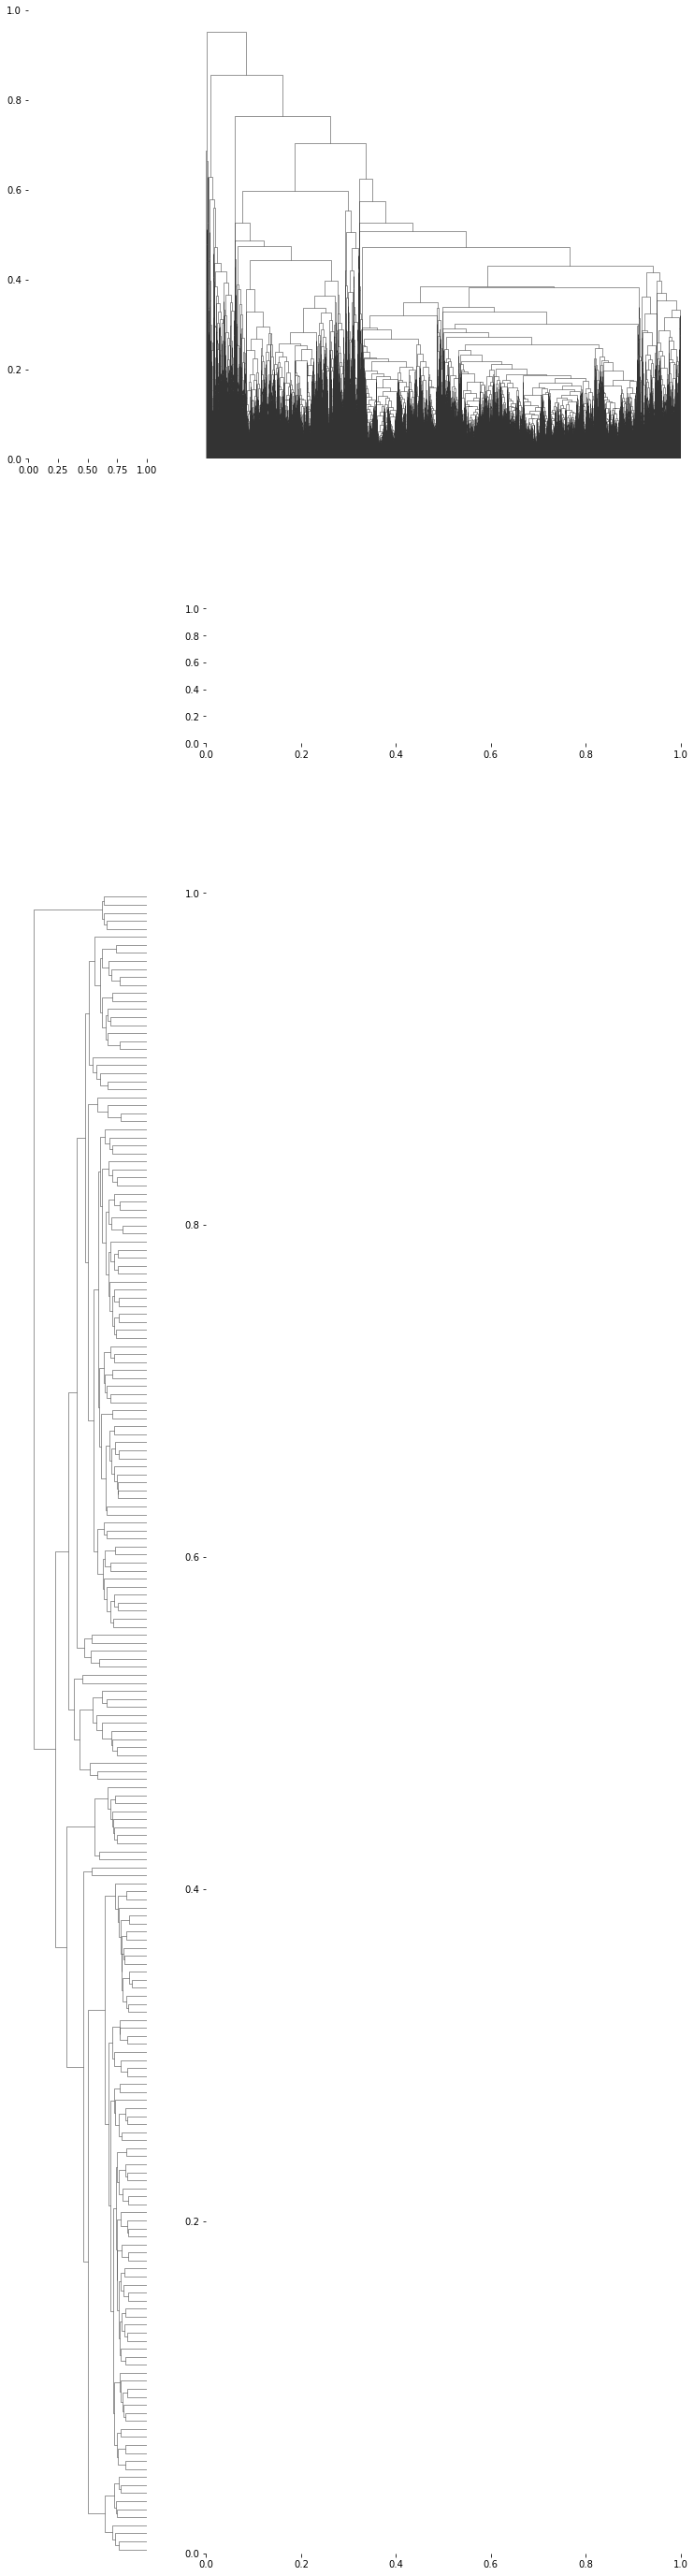

In [11]:
sns.clustermap(prot, metric='euclidean', method='complete', cmap='seismic', mask=prot == mask_na, center=0.,
                figsize=(12.5, 50), col_colors=[stage_col_colors, diagnosis_col_colors])
plt.show()

You could also convert the log2 ratio data to a standard statistic, like z-score.
This can help compress the range, accounting for outliers.

In [ ]:
zdf = ga.T.apply(zscore, ddof=len(ga.columns)-1)
zdf = zdf.T

And examine clustering according to that transformation.

In [ ]:
sns.clustermap(zdf, metric='euclidean', method='complete', cmap='seismic', mask=ga == mask_na, center=0.,
               col_colors=[stage_col_colors, diagnosis_col_colors], figsize=(12.5, 50))
plt.show()

Hopefully, the clustermaps have been drawn.  Columns are labeled aliquot_id:aliquot_submitter_id, according to the PDC data model.  Additional work pre-processing the data, removing outliers and batch effects etc., should always be invested on any large-scale analysis.  This ends this example notebook.

We hope that you found this tutorial useful.  There is also an accompanying tutorial on the PDC site, if you are finding this notebook and have not seen the video.  Please submit any questions or requests to: nci.pdc.help@esacinc.com